# Taller de visualización de datos con Matplotlib y Seaborn

- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

![](https://matplotlib.org/stable/_static/logo_dark.svg)

Matplotlib es una biblioteca de Python utilizada para crear visualizaciones de datos estáticas, animadas e interactivas. Está construida sobre NumPy y puede manejar fácilmente grandes conjuntos de datos para crear diversos tipos de gráficos, como gráficos de líneas, gráficos de barras, diagramas de dispersión, etc.

![](https://seaborn.pydata.org/_static/logo-wide-lightbg.svg)

Seaborn es una biblioteca de Python para crear visualizaciones estadísticas atractivas. Desarrollada sobre Matplotlib e integrada con Pandas, simplifica gráficos complejos como diagramas de líneas, mapas de calor y diagramas de violín con un mínimo de código.

In [ ]:
# Librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# datos
github_datos = "https://raw.githubusercontent.com/fersalme/programacion-python-r/refs/heads/main/datos/palmerpenguins_extended.csv"
df_pinguinos = pd.read_csv(github_datos)

df_pinguinos.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
0,Adelie,Biscoe,53.4,17.8,219.0,5687.0,female,fish,adult,overweight,2021
1,Adelie,Biscoe,49.3,18.1,245.0,6811.0,female,fish,adult,overweight,2021
2,Adelie,Biscoe,55.7,16.6,226.0,5388.0,female,fish,adult,overweight,2021
3,Adelie,Biscoe,38.0,15.6,221.0,6262.0,female,fish,adult,overweight,2021
4,Adelie,Biscoe,60.7,17.9,177.0,4811.0,female,fish,juvenile,overweight,2021


## Gráfico de barras

Un gráfico de barras representa una estimación de la tendencia central de una variable numérica mediante la altura de cada rectángulo y proporciona una indicación de la incertidumbre en torno a dicha estimación mediante barras de error.

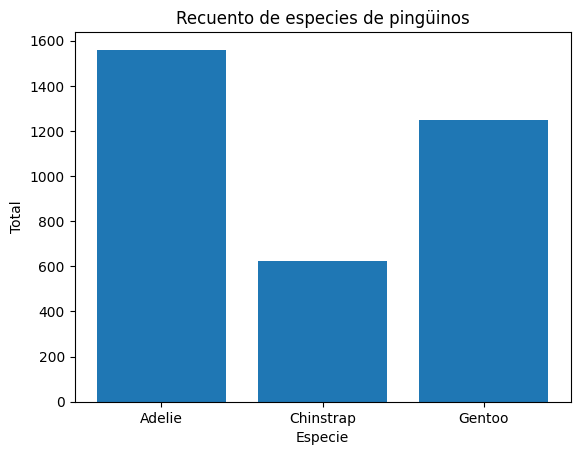

In [ ]:
# total de pinguinos por especie
df_especies = df_pinguinos.groupby("species").size().reset_index(name="recuento")

# matplotlib
plt.bar(df_especies["species"], df_especies["recuento"])
plt.title("Recuento de especies de pingüinos")
plt.xlabel("Especie")
plt.ylabel("Total")
plt.show()

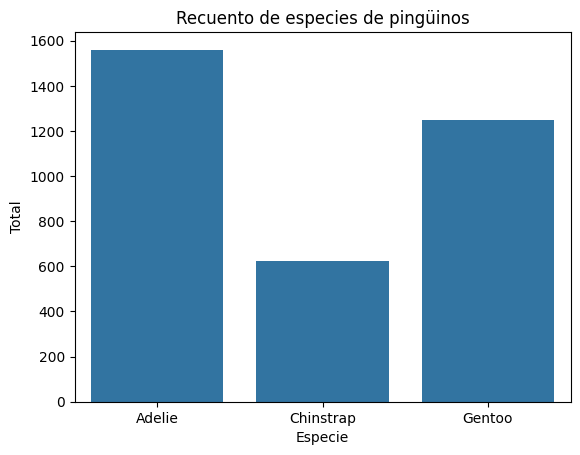

In [ ]:
# seaborn
sns.countplot(x='species', data=df_pinguinos)
plt.title("Recuento de especies de pingüinos")
plt.xlabel("Especie")
plt.ylabel("Total")
plt.show()

## 1. Tarea
- Gráfico de barras del promedio de body_mass_g por especie
- Poner etiquetas de datos en las barras

     species  body_mass_g
0     Adelie  4445.475641
1  Chinstrap  4602.531300
2     Gentoo  5437.640738


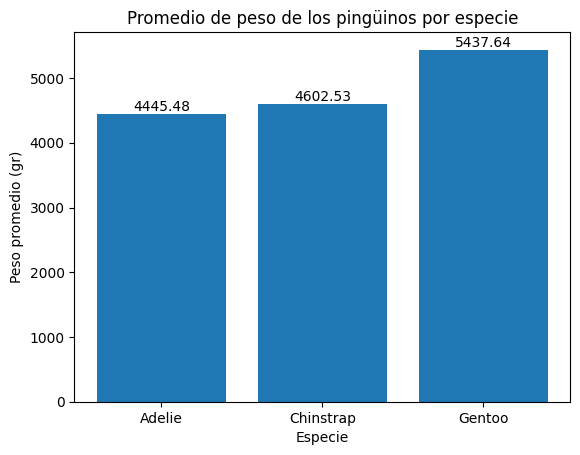

In [ ]:
# Paso 1.
df_promedio_especie = df_pinguinos.groupby("species")["body_mass_g"].mean().reset_index()

print(df_promedio_especie)

# Paso 2. Graficar
plt.bar(df_promedio_especie["species"], df_promedio_especie["body_mass_g"])

# agregar etiquetas de datos (iterar por las filas del dataframe)
for index, row in df_promedio_especie.iterrows():
  plt.text(
      row.name, # posicion x
      row["body_mass_g"], # posicion y
      str(round(row["body_mass_g"], 2)), # label
      ha="center", va="bottom" # estilo label
  )

plt.title("Promedio de peso de los pingüinos por especie")
plt.xlabel("Especie")
plt.ylabel("Peso promedio (gr)")
plt.show()

## Gráfico de líneas

Un gráfico de líneas muestra la relación entre dos variables numéricas, generalmente a lo largo del tiempo. También permite comparar varios grupos mediante diferentes líneas.

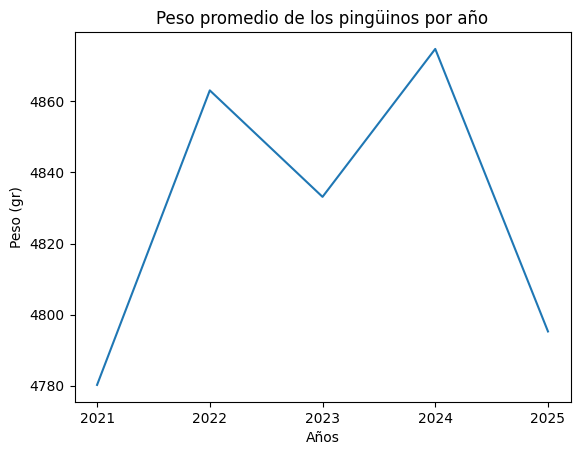

In [ ]:
from matplotlib import markers
# peso promedio de los pinguinos por años
df_peso_pinguinos = df_pinguinos.groupby("year")["body_mass_g"].mean().reset_index()

# matplotlib
plt.plot(df_peso_pinguinos["year"], df_peso_pinguinos["body_mass_g"])
plt.title("Peso promedio de los pingüinos por año")
plt.ylabel('Peso (gr)')
plt.xlabel('Años')
plt.xticks(df_peso_pinguinos["year"]) # Solo los datos reales
plt.show()

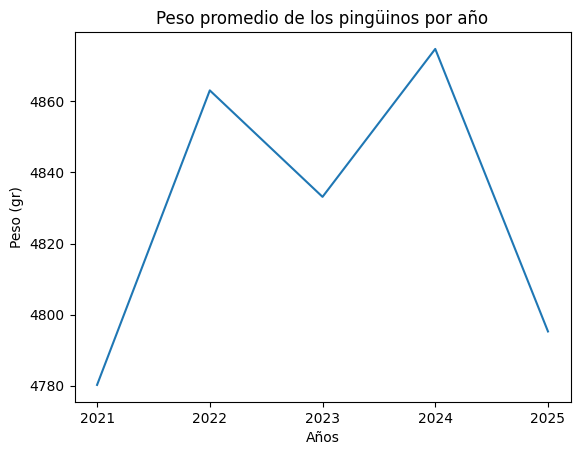

In [ ]:
# seaborn
sns.lineplot(x="year", y="body_mass_g", data=df_peso_pinguinos)

plt.title("Peso promedio de los pingüinos por año")
plt.ylabel('Peso (gr)')
plt.xlabel('Años')
plt.xticks(df_peso_pinguinos["year"]) # Solo los datos reales
plt.show()

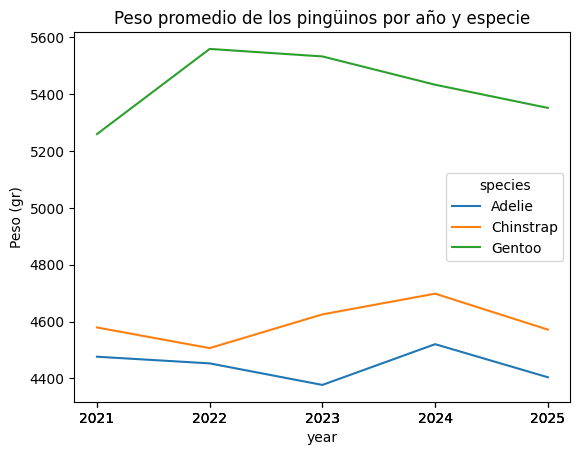

In [ ]:
# promedio peso por year y specie
df_peso_year = df_pinguinos.groupby(["year", "species"])["body_mass_g"].mean().reset_index()

sns.lineplot(x = "year", y = "body_mass_g", hue = "species", data = df_peso_year)
plt.title("Peso promedio de los pingüinos por año y especie")
plt.ylabel('Peso (gr)')
plt.xticks(df_peso_year["year"]) # Solo los datos reales
plt.show()

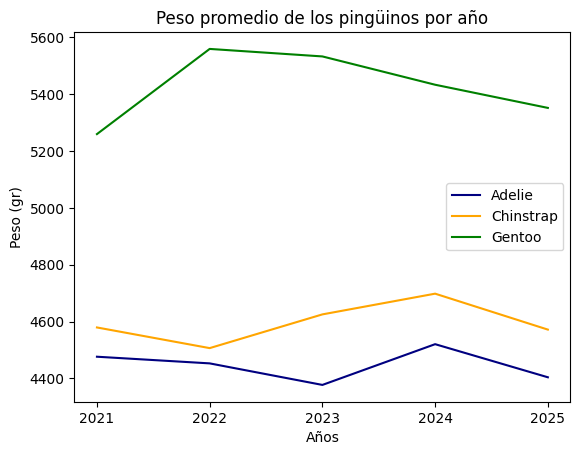

In [ ]:
# paso 1. creo los objetos graficos

fig, ax = plt.subplots()
colores_especies = {"Adelie" : "navy", "Chinstrap" : "orange", "Gentoo" : "green"}

for especie in ["Adelie", "Chinstrap", "Gentoo"]:
  # filtrar los datos de la especie
  df_especie = df_peso_year[df_peso_year["species"] == especie]
  # graficar los datos de la especie
  ax.plot(df_especie["year"], df_especie["body_mass_g"], label = especie, color = colores_especies[especie])

ax.set_title("Peso promedio de los pingüinos por año")
ax.set_ylabel('Peso (gr)')
ax.set_xlabel('Años')
ax.set_xticks(df_peso_pinguinos["year"]) # Solo los datos reales
plt.legend()
plt.show()



## Gráfico de dispersión o scatter

El diagrama de dispersión, o gráfico de dispersión, es un tipo de diagrama estadístico en el que se representa gráficamente un conjunto de datos de dos variables en dos ejes de coordenadas cartesianas.

Por lo tanto, los diagramas de dispersión sirven para analizar la relación entre dos variables estadísticas.


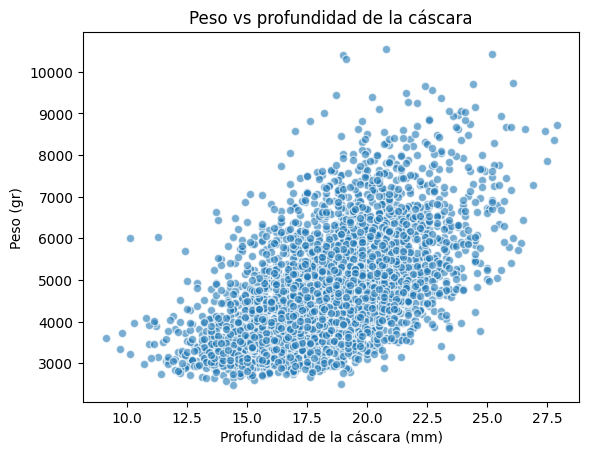

In [ ]:
plt.scatter(df_pinguinos['bill_depth_mm'], df_pinguinos['body_mass_g'], edgecolors='white', alpha=0.6)
plt.title("Peso vs profundidad de la cáscara")
plt.xlabel("Profundidad de la cáscara (mm)")
plt.ylabel("Peso (gr)")
plt.show()

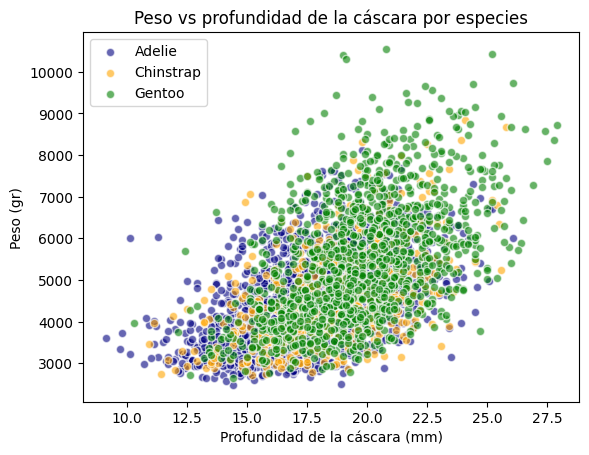

In [ ]:
# Ajustar agregando la especie como color de los puntos

fig, ax = plt.subplots()
colores_especies = {"Adelie" : "navy", "Chinstrap" : "orange", "Gentoo" : "green"}

for especie in ["Adelie", "Chinstrap", "Gentoo"]:
  # filtrar los datos de la especie
  df_especie = df_pinguinos[df_pinguinos["species"] == especie]
  # graficar scatterplot de la especie
  ax.scatter(df_especie['bill_depth_mm'], df_especie['body_mass_g'],
             label = especie,
             color = colores_especies[especie],
             edgecolors='white', alpha=0.6)

ax.set_title("Peso vs profundidad de la cáscara por especies")
ax.set_xlabel("Profundidad de la cáscara (mm)")
ax.set_ylabel("Peso (gr)")
plt.legend()
plt.show()


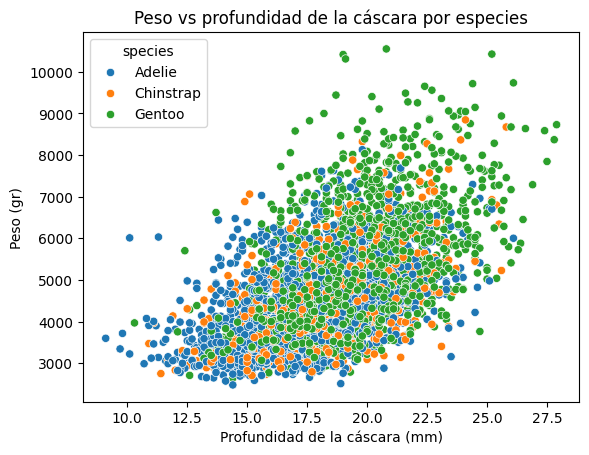

In [ ]:
# Usando seaborn
sns.scatterplot(data=df_pinguinos, x="bill_depth_mm", y="body_mass_g", hue="species")
plt.title("Peso vs profundidad de la cáscara por especies")
plt.xlabel("Profundidad de la cáscara (mm)")
plt.ylabel("Peso (gr)")
plt.show()


# Visualización de distribuciones de datos con Seaborn: Histogramas, gráficos de densidad y boxplots

## Histograma

Un histograma muestra la distribución de los datos agrupando los valores en intervalos. Se utiliza la función `histplot()` para crearlo, donde el eje X representa los intervalos y el eje Y las frecuencias.

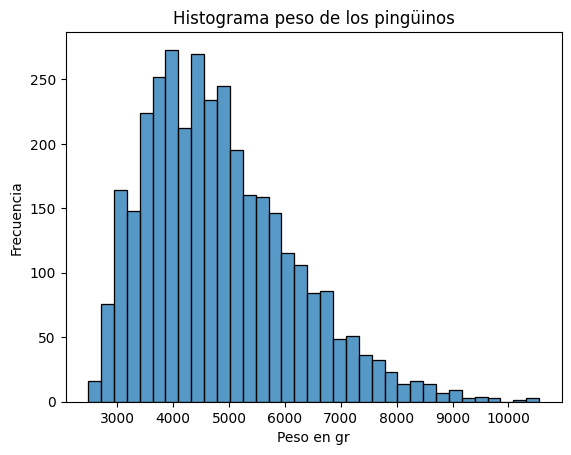

In [ ]:
# por default la función agrupa los datos
sns.histplot(x="body_mass_g", data = df_pinguinos)
plt.title("Histograma peso de los pingüinos")
plt.xlabel("Peso en gr")
plt.ylabel("Frecuencia")
plt.show()

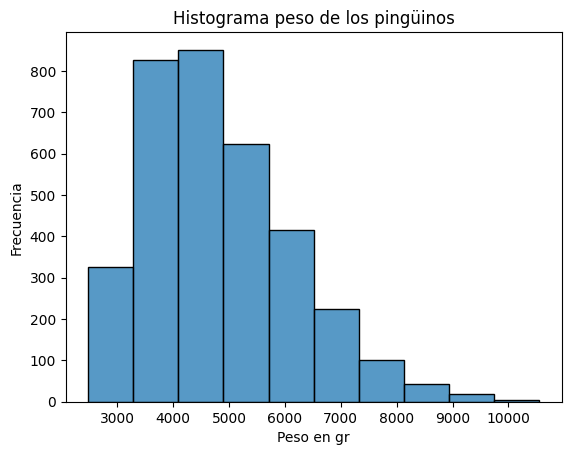

In [ ]:
# con bins ajustamos los grupos
sns.histplot(x="body_mass_g", data = df_pinguinos, bins = 10)
plt.title("Histograma peso de los pingüinos")
plt.xlabel("Peso en gr")
plt.ylabel("Frecuencia")
plt.show()

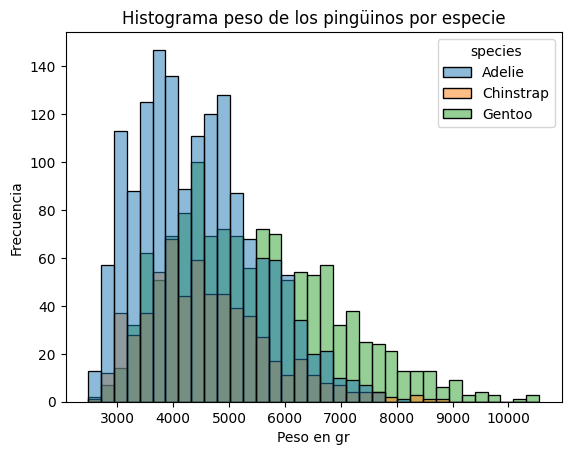

In [ ]:
# La función también ofrece la posibilidad de separar el histograma en base a una característica del conjunto de datos
sns.histplot(x="body_mass_g", data = df_pinguinos, hue = "species")
plt.title("Histograma peso de los pingüinos por especie")
plt.xlabel("Peso en gr")
plt.ylabel("Frecuencia")
plt.show()

Por defecto se muestra el número de ocurrencias que se observa en cada uno de los bins. Si no se desea mostrar esa información se puede usar la propiedad stat para indicar que se muestre la probabilidad ('probability'), el porcentaje ('percent'), la densidad ('density') o la frecuencia ('frequency').

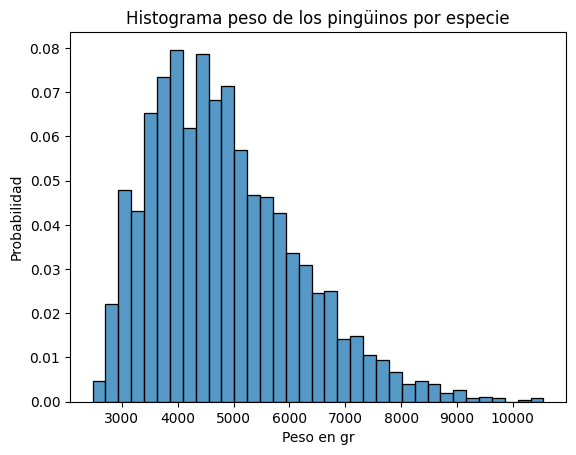

In [ ]:
# Crear un histograma de la columna "body_mass_g"
sns.histplot(data=df_pinguinos, x='body_mass_g', stat='probability')
plt.title("Histograma peso de los pingüinos por especie")
plt.xlabel("Peso en gr")
plt.ylabel("Probabilidad")
plt.show()

## Gráficos de densidad

El gráfico KDE (Estimación de Densidad del Kernel) se utiliza para visualizar la densidad de probabilidad de una variable continua en diferentes valores. También permite generar un único gráfico para múltiples muestras, lo que facilita una visualización de datos más eficiente.

A diferencia de los histogramas, en los gráficos de densidad la distribución de la variable se muestra como una función continua. Para lo que se crea una estimación de la densidad de los datos en cada uno de los puntos de la variable empleando una función de kernel gaussiano.

En Seaborn la creación de estos gráficos se puede hacer mediante la función kdeplot(), la cual necesita los mismos parámetros básicos que histplot() (data y x).

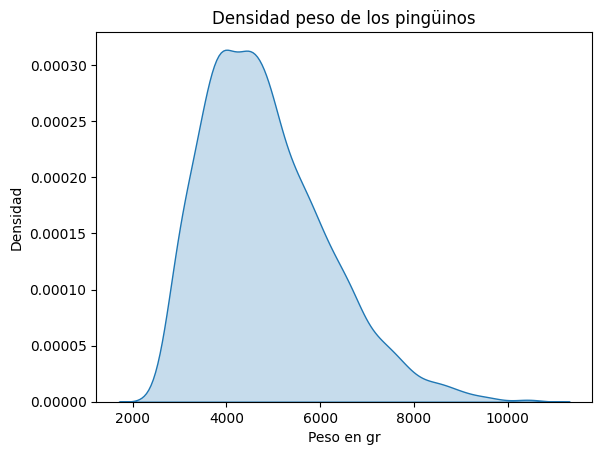

In [ ]:
# Crear un gráfico de densidad body_mass_g
sns.kdeplot(x="body_mass_g", data = df_pinguinos, fill = True)
plt.title("Densidad peso de los pingüinos")
plt.xlabel("Peso en gr")
plt.ylabel("Densidad")
plt.show()

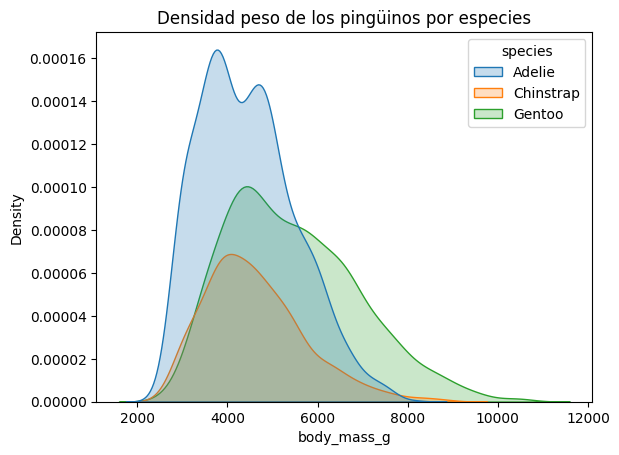

In [ ]:
# seaborn
sns.kdeplot(x="body_mass_g", hue = "species", data = df_pinguinos, fill = True)
plt.title("Densidad peso de los pingüinos por especies")
plt.show()

## Boxplot

Un diagrama de caja (también, diagrama de caja y bigotes o box plot) es un método estandarizado para representar gráficamente una serie de datos numéricos a través de sus cuartiles. De esta manera, se muestran a simple vista la mediana y los cuartiles de los datos, y también pueden representarse sus valores atípicos.

Seaborn dispone de la función boxplot() para crear diagramas de caja. En este caso es además de los parámetros usados en los casos anteriores es necesario indicar también la variable por la que se dividen los datos, lo que se hace mediante la propiedad y.

![](https://www.laboneconsultoria.com.br/wp-content/uploads/2018/07/Boxplot-04.png)


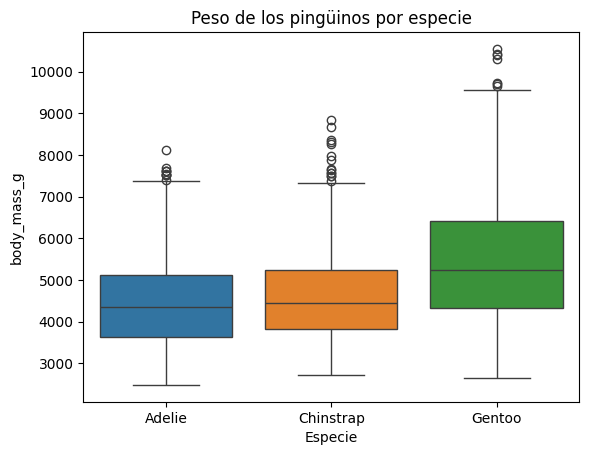

In [ ]:
# Crear un diagrama de caja de "body_mass_g" agrupado por "species"
sns.boxplot(data=df_pinguinos, x='species', y='body_mass_g', hue='species')
plt.title("Peso de los pingüinos por especie")
plt.xlabel("Especie")
plt.show()

## heatmaps

Un heatmap, o mapa de calor, es una representación visual de datos en la que los valores individuales se traducen en colores dentro de una matriz o superficie. Esta escala cromática facilita la identificación de patrones, tendencias y áreas de mayor o menor actividad de forma rápida e intuitiva.

El término “calor” hace referencia a la intensidad de los datos: los colores cálidos como el rojo, naranja o amarillo indican mayor concentración o actividad, mientras que los colores fríos como el azul, verde o morado representan menor interacción o presencia.

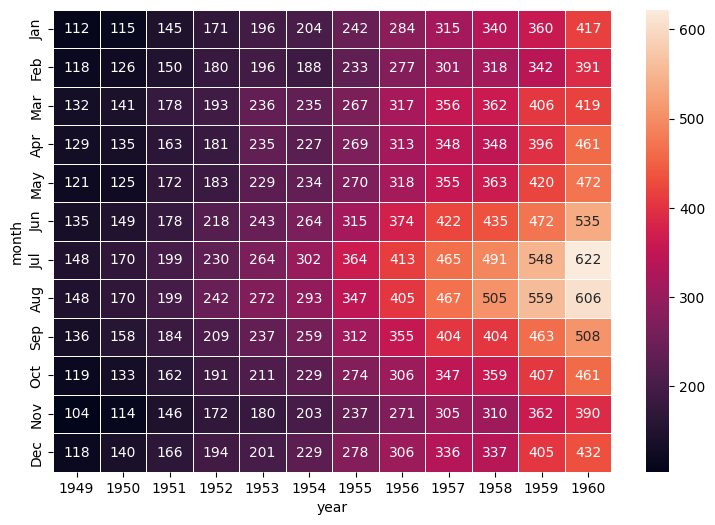

In [ ]:
# Load the example flights dataset and convert to long-form
flights_long = sns.load_dataset("flights")
flights = (
    flights_long
    .pivot(index="month", columns="year", values="passengers")
)

# Draw a heatmap with the numeric values in each cell
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(flights, annot=True, fmt="d", linewidths=.5, ax=ax)
plt.show()


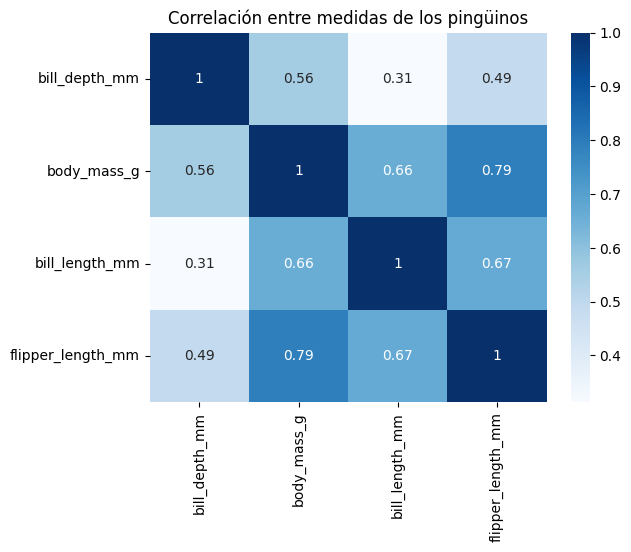

In [ ]:
# Seleccionamos solo las columnas numéricas para calcular la correlación
corr = df_pinguinos[['bill_depth_mm', 'body_mass_g', 'bill_length_mm', 'flipper_length_mm']].corr()

# Creamos el heatmap
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlación entre medidas de los pingüinos")
plt.show()

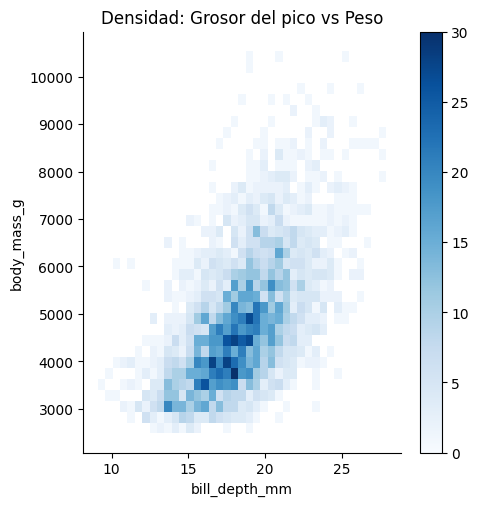

In [ ]:
# Gráfico de densidad (parecido a un heatmap pero para dos variables)
sns.displot(data=df_pinguinos, x='bill_depth_mm', y='body_mass_g', cbar=True, cmap='Blues')
plt.title("Densidad: Grosor del pico vs Peso")
plt.show()

## Scatterplot Matrix

Un Scatterplot Matrix (Matriz de Diagramas de Dispersión) es una herramienta de visualización que permite examinar las relaciones entre múltiples variables numéricas en un solo gráfico.

En lugar de crear gráficos uno por uno, generas una cuadrícula de N×N (donde N es el número de variables), facilitando la detección de correlaciones, patrones y valores atípicos de forma simultánea.

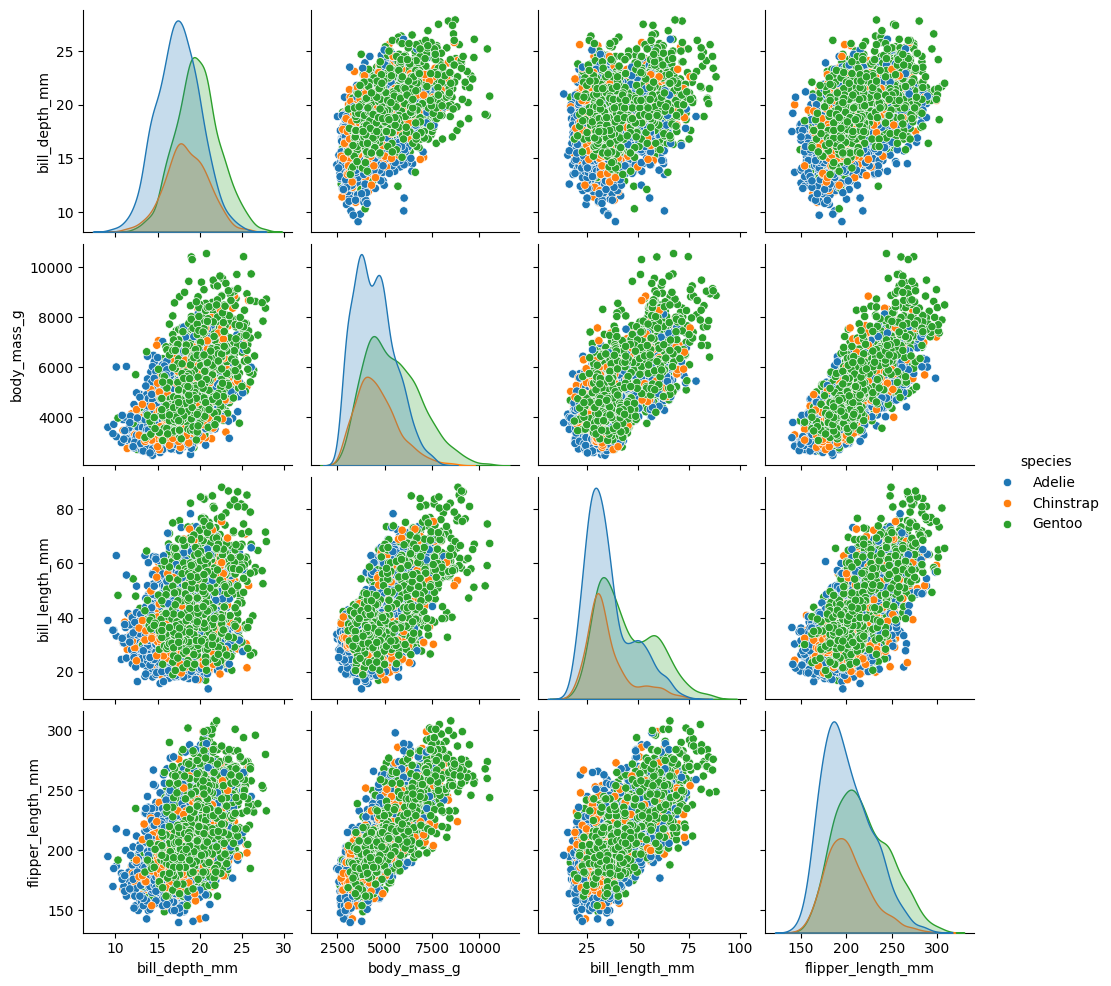

In [ ]:
# relacion multiple entre variales numericas en base pinguinos
df_num = df_pinguinos[['bill_depth_mm', 'body_mass_g', 'bill_length_mm', 'flipper_length_mm', 'species']]
sns.pairplot(df_num, hue="species")
plt.show()

# Creación de dashboards interactivos con Matplotlib y Seaborn

Un dashboard (o tablero de control) es una herramienta de gestión de la información que visualiza. Su objetivo principal es transformar datos complejos en información visual fácil de entender.

## ¿Qué es un widget?

Los widgets en Python son objetos que tienen una representación en el navegador (Jupyter notebook en este ejemplo). Por ejemplo, los widgets pueden tener forma de una caja de texto, un desplegable, una casilla de verificación, etc. Cuando utilizamos los widgets, estamos incorporando controles interactivos al notebook de Jupyter.
Ipywidgets

La librería ipywidgets nos permite transformar un notebook de Jupyter en un explorador de datos interactivo.

El concepto fundamental es el bucle de retroalimentación: un widget captura una entrada del usuario, esta entrada se pasa como argumento a una función de Python, y esa función redibuja el gráfico estático de Matplotlib/Seaborn.

## Los Componentes del Dashboard

Para que el dashboard funcione, necesitamos tres piezas clave:

- Los Datos : Generalmente un DataFrame de Pandas que será filtrado.
- Los Widgets : Controles visuales (botones, sliders, menús) que capturan la interacción.
- La Función de Renderizado: Una función que contiene el código de Seaborn y que se "limpia" y se "dibuja" cada vez que un widget cambia.

## El flujo de trabajo con interactive

La forma más sencilla de conectar todo es usar la función interact de la librería ipywidgets.

- Paso A: Defines una función que acepte parámetros (ej. especie, color).

- Paso B: Dentro de la función, usas esos parámetros para filtrar el DataFrame: df[df['species'] == especie].

- Paso C: Llamas a interact(tu_funcion, especie=['Adelie', 'Gentoo']). Python creará automáticamente un menú desplegable porque le pasaste una lista.

## Tipos de Widgets Comunes

| Categoría | Widget | Uso Típico en Dashboards |
| :--- | :--- | :--- |
| **Numéricos** | `IntSlider` | Seleccionar un año o cantidad entera. |
| | `FloatSlider` | Ajustar parámetros con decimales (ej. opacidad). |
| | `IntRangeSlider` | Definir rangos (ej. filtrar pesos entre 3000g y 5000g). |
| **Booleanos** | `Checkbox` | Activar/Desactivar elementos (ej. mostrar rejilla). |
| | `ToggleButton` | Botón interruptor para cambiar estados visuales. |
| **Selección** | `Dropdown` | Menú desplegable para elegir una categoría única. |
| | `RadioButtons` | Selección única entre opciones visibles. |
| | `SelectMultiple` | Seleccionar varias categorías para comparar. |
| **Texto** | `Text` | Ingresar títulos o etiquetas personalizadas. |
| | `Label` | Mostrar leyendas o explicaciones estáticas. |
| **Estética** | `ColorPicker` | Cambiar el color de las series de datos. |
| | `DatePicker` | Filtrar datos basados en fechas del calendario. |
| **Layout** | `HBox` | Organizar widgets horizontalmente (lado a lado). |
| | `VBox` | Organizar widgets verticalmente (uno sobre otro). |

## Gestión del Layout (Organización)

Un dashboard no es solo un gráfico; es cómo se presentan los controles. Para organizar el espacio, se utilizan contenedores:

- VBox (Vertical Box): Apila los widgets uno encima de otro. Es ideal para una barra lateral de controles.

- HBox (Horizontal Box): Coloca elementos uno al lado del otro. Se usa para poner la columna de controles a la izquierda y el gráfico a la derecha.

In [ ]:
# Ejemplos de widgets sencillos
import ipywidgets as widgets

widgets.IntSlider(min=0, max=10, step=1, orientation='horizontal', description= "Felicidad:")

IntSlider(value=0, description='Felicidad:', max=10)

In [ ]:
from ipywidgets import interact

estados_felicidad = {
    0: "😭", 1: "😢", 2: "☹️",
    3: "🙁", 4: "😐", 5: "🙂",
    6: "😊", 7: "😁", 8: "😄",
    9: "🥳", 10: "🤩"
}

slider = widgets.IntSlider(min=0, max=10, step=1, description="Felicidad")

@interact(nivel=slider)
def mostrar_nivel(nivel):
    print(f"Tu nivel de felicidad es: {nivel} {estados_felicidad[nivel]}")

interactive(children=(IntSlider(value=0, description='Felicidad', max=10), Output()), _dom_classes=('widget-in…

In [ ]:
from ipywidgets import widgets, interact, interactive, HBox, VBox

# 1. Preparación de datos
df_pinguinos = sns.load_dataset("penguins").dropna()

# 2. Definición de la función que construye el dashboard
def actualizar_dashboard(especie, color_map, mostrar_puntos):
    # Filtrar datos según la selección
    df_filtrado = df_pinguinos[df_pinguinos['species'] == especie]

    # Crear la figura con dos subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    plt.subplots_adjust(top=0.85)
    fig.suptitle(f'Análisis de la Especie: {especie}', fontsize=16, fontweight='bold')

    # Gráfico 1: Relación Largo vs Ancho del Pico (Scatterplot)
    sns.scatterplot(
        data=df_filtrado,
        x="bill_length_mm",
        y="bill_depth_mm",
        hue="sex",
        ax=ax1,
        s=100 if mostrar_puntos else 0, # Control interactivo de visibilidad
        alpha=0.7
    )
    ax1.set_title("Dimensiones del Pico por Sexo")
    ax1.set_xlabel("Largo del Pico (mm)")
    ax1.set_ylabel("Ancho del Pico (mm)")

    # Gráfico 2: Distribución de Masa Corporal (Histplot)
    sns.histplot(
        data=df_filtrado,
        x="body_mass_g",
        kde=True,
        color=color_map,
        ax=ax2
    )
    ax2.set_title("Distribución del Peso")
    ax2.set_xlabel("Masa Corporal (gr)")
    ax2.set_ylabel("Frecuencia")

    plt.show()

# 3. Creación de los Widgets (Controles)
dropdown_especie = widgets.Dropdown(
    options=df_pinguinos['species'].unique(),
    value='Adelie',
    description='Especie:',
)

picker_color = widgets.ColorPicker(
    concise=False,
    description='Color Hist:',
    value='#3498db'
)

checkbox_puntos = widgets.Checkbox(
    value=True,
    description='Mostrar Puntos',
)

# 4. Conectar los widgets con la función
panel = widgets.interactive_output(
    actualizar_dashboard,
    {
        'especie': dropdown_especie,
        'color_map': picker_color,
        'mostrar_puntos': checkbox_puntos
    }
)

# 5. Organizar el Layout
controles = VBox([dropdown_especie, picker_color, checkbox_puntos])
dashboard = HBox([controles, panel])

# 6. Mostrar el Dashboard
display(dashboard)

